# 3HDM-S₃ scalar parameter space under theory constraints

**A research notebook, not a tutorial.** It assumes
[`examples/THDM_S3_Tutorial.ipynb`](../../examples/THDM_S3_Tutorial.ipynb), which derives
the S₃-invariant potential, checks its gauge and S₃ invariance, and shows how the tadpoles
force the √3 vacuum alignment. Conclusions here are *findings* and may be revised.

**The question:** which region of the eight-dimensional quartic parameter space of the
S₃-symmetric three-Higgs-doublet model survives the combined theory constraints, and what
scalar spectrum does it predict?

## What this notebook establishes

1. **A vacuum bug in the tutorial benchmark** — the aligned vacuum sits at $v=155$ GeV,
   not 246 (§2).
2. **The parameter dictionary to the literature, derived rather than assumed** (§4). The
   two doublet bases genuinely differ; feynlag proves it. Matching feynlag's independently
   derived masses to [GomezBock21] Eqs. (30)–(33) fixes the dictionary and simultaneously
   validates the whole 3HDM-S₃ chain against published closed forms.
3. **The boundedness conditions in the literature are not sufficient** (§5). Testing them
   directly against the potential produces explicit counterexamples: λ points that satisfy
   [DasDey14] Eq. (4) yet have a field direction along which $V_4<0$. The cause is
   diagnosed in closed form — Eq. (4g) is a single point of a curve that must be
   non-negative everywhere — and a corrected condition is derived and used.
4. **A vectorized scan** over $(\lambda_1\ldots\lambda_8,\theta)$ that *characterizes* the
   viable region instead of returning the first lucky point (§6–§8).

## How to read it

Every step is shown as an equation and then **checked by an `assert`**, so nothing here
rests on a print statement that could quietly change. Verification cells end in a `✓` line.
Imported results carry an inline `[Tag]` resolving in the [references](#10-references).

| symbol | meaning |
|---|---|
| $v=246$ GeV | electroweak scale, $\sqrt{v_1^2+v_2^2+v_S^2}$ &nbsp; [GomezBock21] Eq. (8) |
| $\theta$ | vacuum angle, $\tan\theta=v_{12}/v_S$ with $v_{12}=\sqrt{v_1^2+v_2^2}$ |
| $\varphi$ | doublet-plane angle, $\tan\varphi=v_2/v_1$; the alignment forces $\varphi=60°$ |
| $h_0,H_1,H_2$ | CP-even scalars &nbsp;&nbsp; $A_1,A_2$ CP-odd &nbsp;&nbsp; $H^\pm_1,H^\pm_2$ charged |
| $\lambda_1\ldots\lambda_8$ | quartic couplings in **feynlag's** basis (see §4) |

> **Kernel.** Executed with the plain `python3` kernel, not the repo's `lagrangian` kernel,
> which has no `numpy`/`matplotlib`. See `NOTES.md`.


In [ ]:
import json, logging, math, sys, time
from pathlib import Path

import numpy as np
import sympy as sp
import matplotlib
logging.getLogger("matplotlib").setLevel(logging.CRITICAL)  # a broken personal
import matplotlib.pyplot as plt                             # stylelib file is noisy

sys.path.insert(0, str(Path.cwd()))
from model import (build_model, mass_matrices, rotation, diagonal_blocks,
                   cp_even_block, cp_even_angle, spectrum_function, aligned_vevs,
                   alignment_residual, vacuum_scale, quartic_potential,
                   numeric_bfb_min, check_spectrum_against_eigenvals,
                   check_sectors_against_eigenvals, SPECTRUM_KEYS, V_EW,
                   component_symbols, NEUTRAL_INDICES, CHARGED_INDICES)
from constraints import (bfb_conditions, bfb_mask, unitarity_mask, unitarity_eigenvalues,
                         neutral_real_bfb_min, neutral_real_bfb_mask, strict_bfb_mask,
                         theory_mask, constraint_report)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
sp.init_printing(use_latex="mathjax")   # crisp, selectable equations (not PNGs)

def ok(msg):
    print("✓", msg)

print("electroweak scale:", V_EW, "GeV")


electroweak scale: 246.0 GeV


---
## 1. The model

Three Higgs doublets, all with $(SU(2)_L,U(1)_Y)=(\mathbf 2,\tfrac12)$. Under S₃ the pair
$(H_1,H_2)$ is a **doublet** and $H_S$ a **singlet**. Writing
$x_{ij}\equiv H_i^\dagger H_j$ and $s_i \equiv H_S^\dagger H_i$, the S₃ Clebsch–Gordan
decomposition $\mathbf2\otimes\mathbf2=\mathbf1\oplus\mathbf1'\oplus\mathbf2$ in feynlag's
real-orthogonal irrep basis gives

$$\underbrace{x_{11}+x_{22}}_{\mathbf 1},\qquad
\underbrace{x_{12}-x_{21}}_{\mathbf 1'},\qquad
\underbrace{d_2=\big(x_{11}-x_{22},\,-(x_{12}+x_{21})\big)}_{\mathbf 2},$$

and the most general renormalizable S₃- and gauge-invariant potential is

$$
V=\mu_1^2\,(x_{11}+x_{22})+\mu_0^2\,x_{SS}
+\lambda_1(x_{11}+x_{22})^2+\lambda_2(x_{12}-x_{21})^2+\lambda_3\,|d_2|^2
$$
$$
+\;\lambda_4\big[s_1 d_2^{(1)}+s_2 d_2^{(2)}+\text{h.c.}\big]
+\lambda_5\,x_{SS}(x_{11}+x_{22})
+\lambda_6\big[s_1 x_{1S}+s_2 x_{2S}\big]
+\lambda_7\big[s_1^2+s_2^2+\text{h.c.}\big]
+\lambda_8\,x_{SS}^2 .
$$

This is `examples/thdm_s3.py`'s potential, rebuilt by `model.build_model`. Two other
parametrizations of the *same* potential appear in the literature — [DasDey14] Eq. (3c)
also uses $\lambda_1\ldots\lambda_8$, and [GomezBock21] Eq. (2)/(6) uses $a,\ldots,h$.
**They are not the same $\lambda$'s**; §4 settles the dictionary.

First: is the potential actually invariant? `build_model(check=True)` runs feynlag's gauge,
S₃, hermiticity and mass-dimension checks.


In [ ]:
t0 = time.time()
m = build_model(check=True)          # raises if any invariance check fails
report = m.model.check_invariance()
print("built and checked in %.1f s" % (time.time() - t0))
print(report, "  failures:", report.failures)

assert report.ok and report.checked > 0
ok("potential passes all %d invariance checks (gauge, S3, hermiticity, mass dimension)"
   % report.checked)


built and checked in 10.8 s
InvarianceReport(5 checks, OK)   failures: []
✓ potential passes all 5 invariance checks (gauge, S3, hermiticity, mass dimension)


A check that cannot fail proves nothing. The same machinery must **reject** a term S₃
forbids — here $x_{SS}\,(x_{11}-x_{22})$, which is the first component of a doublet, not a
singlet:


In [ ]:
from feynlag import check_discrete_invariance, dag

H1, H2, HS = m.doublets
bra = lambda A, B: (dag(A) * B.mat)[0]
x11, x22, x12, x21 = bra(H1, H1), bra(H2, H2), bra(H1, H2), bra(H2, H1)
xSS = bra(HS, HS)

allowed, _ = check_discrete_invariance(xSS * (x11 + x22), m.s3)   # the lambda5 invariant
forbidden, _ = check_discrete_invariance(xSS * (x11 - x22), m.s3) # a doublet component

print("S3-invariant   x_SS (x11 + x22) :", allowed)
print("S3-invariant   x_SS (x11 - x22) :", forbidden)
assert allowed and not forbidden
ok("the invariance check discriminates: it accepts the singlet and rejects the doublet")


S3-invariant   x_SS (x11 + x22) : True
S3-invariant   x_SS (x11 - x22) : False
✓ the invariance check discriminates: it accepts the singlet and rejects the doublet


---
## 2. The vacuum

### 2.1 The √3 alignment is forced, not chosen

Each neutral component gets a VEV, $H_i^0\to(v_i+h_i+ia_i)/\sqrt2$, and the three tadpole
conditions $\partial V/\partial v_i=0$ must hold. That is **three** equations for **two**
free mass parameters $(\mu_0^2,\mu_1^2)$ — the system is over-constrained, and this is the
point of the model rather than a defect. Solving two of them and substituting into the
third leaves a residual which must vanish on its own. `model.alignment_residual` computes
exactly that:


In [ ]:
tad = m.model.tadpoles()
print("the three tadpole conditions dV/dv_i = 0:")
for sym in (m.v1.s, m.v2.s, m.vS.s):
    print("  d/d%s:" % sym)
    display(sp.factor(sp.expand(tad[sym])))

residual = alignment_residual(m)
print("\nresidual of the third condition once the other two fix (mu0^2, mu1^2):")
display(sp.Eq(residual, 0))

roots = sp.solve(sp.Eq(residual, 0), m.v2.s)
print("\nroots for v2 (v1, v_S > 0):", roots)
assert sp.sqrt(3) * m.v1.s in roots
ok(r"the vacuum alignment v2 = sqrt(3) v1 is a *consequence* of the tadpole system")


the three tadpole conditions dV/dv_i = 0:
  d/dv_1:


       3             2          3             2          2              2      ↪
2⋅λ₁⋅v₁  + 2⋅λ₁⋅v₁⋅v₂  + 2⋅λ₃⋅v₁  + 2⋅λ₃⋅v₁⋅v₂  + 3⋅λ₄⋅v₁ ⋅v_S - 3⋅λ₄⋅v₂ ⋅v_S  ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                 2             ↪

↪            2            2              2             
↪ + λ₅⋅v₁⋅v_S  + λ₆⋅v₁⋅v_S  + 2⋅λ₇⋅v₁⋅v_S  + 2⋅mu1sq⋅v₁
↪ ─────────────────────────────────────────────────────
↪                                                      

  d/dv_2:


   ⎛       2          2          2          2                       2          ↪
v₂⋅⎝2⋅λ₁⋅v₁  + 2⋅λ₁⋅v₂  + 2⋅λ₃⋅v₁  + 2⋅λ₃⋅v₂  - 6⋅λ₄⋅v₁⋅v_S + λ₅⋅v_S  + λ₆⋅v_S ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                  2                            ↪

↪ 2           2          ⎞
↪   + 2⋅λ₇⋅v_S  + 2⋅mu1sq⎠
↪ ────────────────────────
↪                         

  d/dv_S:


     3             2        2            2            2            2           ↪
λ₄⋅v₁  - 3⋅λ₄⋅v₁⋅v₂  + λ₅⋅v₁ ⋅v_S + λ₅⋅v₂ ⋅v_S + λ₆⋅v₁ ⋅v_S + λ₆⋅v₂ ⋅v_S + 2⋅λ ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                               2               ↪

↪     2              2               3              
↪ ₇⋅v₁ ⋅v_S + 2⋅λ₇⋅v₂ ⋅v_S + 2⋅λ₈⋅v_S  + 2⋅mu0sq⋅v_S
↪ ──────────────────────────────────────────────────
↪                                                   


residual of the third condition once the other two fix (mu0^2, mu1^2):


         ⎛    2     2⎞    
3⋅λ₄⋅v_S⋅⎝3⋅v₁  - v₂ ⎠    
────────────────────── = 0
          2               


roots for v2 (v1, v_S > 0): [sqrt(3)*v_1]
✓ the vacuum alignment v2 = sqrt(3) v1 is a *consequence* of the tadpole system


The residual factorizes as $\tfrac32\lambda_4 v_S(3v_1^2-v_2^2)$, so — for $\lambda_4\neq0$
and $v_S\neq0$ — the vacuum must satisfy

$$v_2=\sqrt3\,v_1 .$$

This is [GomezBock21] Eq. (13). Their basis has the roles of $v_1$ and $v_2$ swapped
relative to feynlag's real-orthogonal irrep basis, so they write $v_1=\sqrt3\,v_2$; §4
shows why the two doublet bases differ.

### 2.2 The tutorial benchmark sits at the wrong electroweak scale

A second condition constrains the VEVs — the electroweak scale itself,
$\sqrt{v_1^2+v_2^2+v_S^2}=v=246$ GeV ([GomezBock21] Eq. 8). The tutorial picks
$(v_1,v_2,v_S)=(200,115,80)$ precisely to satisfy it, then imposes the alignment as the
substitution `align = {v1: v2/sqrt(3)}` — which **replaces** $v_1=200$ by $115/\sqrt3=66.4$
and never re-checks the scale:


In [ ]:
v2_t, vS_t = 115.0, 80.0                 # the tutorial's numbers
v1_t = v2_t / math.sqrt(3)               # what `align` actually substitutes

print("before alignment: (200, 115, 80)        -> v = %6.2f GeV" %
      vacuum_scale(200.0, v2_t, vS_t))
print("after  alignment: (%.2f, %.1f, %.1f)   -> v = %6.2f GeV   <-- not 246" %
      (v1_t, v2_t, vS_t, vacuum_scale(v1_t, v2_t, vS_t)))
assert abs(vacuum_scale(v1_t, v2_t, vS_t) - V_EW) > 50
ok("confirmed: the tutorial's aligned vacuum misses the electroweak scale")


before alignment: (200, 115, 80)        -> v = 244.18 GeV
after  alignment: (66.40, 115.0, 80.0)   -> v = 155.03 GeV   <-- not 246
✓ confirmed: the tutorial's aligned vacuum misses the electroweak scale


### 2.3 Imposing both conditions at once

The two conditions together leave a one-parameter family, which `aligned_vevs`
parametrizes by the same angle θ the geometric rotation uses ([GomezBock21] Eq. 24):

$$v_{12}\equiv\sqrt{v_1^2+v_2^2}=v\sin\theta,\qquad v_S=v\cos\theta,$$

and the alignment then fixes

$$v_1=\tfrac12 v_{12},\qquad v_2=\tfrac{\sqrt3}{2}v_{12}
\qquad\Longrightarrow\qquad \tan\varphi=\frac{v_2}{v_1}=\sqrt3,\quad\varphi=60°$$

for **every** θ — the doublet-plane angle is fixed by the alignment alone.


In [ ]:
for th in (0.15, 0.5, 1.0286, 1.3, 1.5):
    v1, v2, vS = aligned_vevs(th)
    assert abs(v2 / v1 - math.sqrt(3)) < 1e-12          # alignment
    assert abs(vacuum_scale(v1, v2, vS) - V_EW) < 1e-9  # electroweak scale
    print("theta = %.4f  ->  (%7.2f, %7.2f, %7.2f)   v = %.4f   v2/v1 = %.9f"
          % (th, v1, v2, vS, vacuum_scale(v1, v2, vS), v2 / v1))
ok("aligned_vevs satisfies BOTH vacuum conditions simultaneously, for every theta")

theta_t = math.atan2(math.hypot(v1_t, v2_t), vS_t)      # the tutorial's direction
v1, v2, vS = aligned_vevs(theta_t)
print("\nthe tutorial's direction, rescaled: (%.2f, %.2f, %.2f) at theta = %.2f deg"
      % (v1, v2, vS, math.degrees(theta_t)))


theta = 0.1500  ->  (  18.38,   31.84,  243.24)   v = 246.0000   v2/v1 = 1.732050808
theta = 0.5000  ->  (  58.97,  102.14,  215.89)   v = 246.0000   v2/v1 = 1.732050808
theta = 1.0286  ->  ( 105.36,  182.49,  126.94)   v = 246.0000   v2/v1 = 1.732050808
theta = 1.3000  ->  ( 118.52,  205.28,   65.80)   v = 246.0000   v2/v1 = 1.732050808
theta = 1.5000  ->  ( 122.69,  212.51,   17.40)   v = 246.0000   v2/v1 = 1.732050808
✓ aligned_vevs satisfies BOTH vacuum conditions simultaneously, for every theta

the tutorial's direction, rescaled: (105.36, 182.48, 126.95) at theta = 58.93 deg


### 2.4 How much does this matter?

Every entry of every mass matrix is a quartic coupling times two VEVs, so each mass² is
**homogeneous of degree 2** in the VEVs. At fixed λ and θ the whole spectrum therefore just
rescales, by $(246/155.03)^2$. That is worth verifying rather than asserting:


In [ ]:
M_S, M_A, M_C = mass_matrices(m)
D_S, D_A, D_C = diagonal_blocks(m)

s = sp.Symbol("s", positive=True)
rescale = {m.v2.s: s * m.v2.s, m.vS.s: s * m.vS.s}
homogeneous = all(sp.simplify(D[i, j].subs(rescale) - s**2 * D[i, j]) == 0
                  for D in (D_S, D_A, D_C) for i in range(3) for j in range(3))
assert homogeneous
ok("every mass-matrix entry is homogeneous of degree 2 in the VEVs (27 entries)")

spec = spectrum_function(m)
naive_lams = [0.05 * k for k in range(1, 9)]        # the tutorial's benchmark lambdas
s_tut, s_fix = spec(naive_lams, v2_t, vS_t), spec(naive_lams, v2, vS)
expected = (V_EW / vacuum_scale(v1_t, v2_t, vS_t)) ** 2

print("\n%-6s %14s %14s %8s" % ("state", "tutorial m^2", "rescaled m^2", "ratio"))
for k in SPECTRUM_KEYS:
    print("%-6s %14.1f %14.1f %8.3f" % (k, s_tut[k], s_fix[k], s_fix[k] / s_tut[k]))
    assert abs(s_fix[k] / s_tut[k] - expected) < 1e-9
print("\nexpected ratio (246/155.03)^2 = %.3f" % expected)
ok("every mass is low by exactly 246/155.03 = %.3f in the tutorial" % math.sqrt(expected))


✓ every mass-matrix entry is homogeneous of degree 2 in the VEVs (27 entries)

state    tutorial m^2   rescaled m^2    ratio
h0             9560.9        24074.4    2.518
H1            14214.6        35792.5    2.518
H2            -2301.3        -5794.8    2.518
A1            -7985.0       -20106.4    2.518
A2           -12834.1       -32316.3    2.518
Hpm1          -3178.4        -8003.2    2.518
Hpm2          -8027.4       -20213.1    2.518

expected ratio (246/155.03)^2 = 2.518
✓ every mass is low by exactly 246/155.03 = 1.587 in the tutorial


---
## 3. The three sectors

`model.py` lifts the tutorial's notebook-local algebra into importable functions. On the
aligned vacuum with the tadpole solution substituted, feynlag produces three 3×3 mass
matrices: CP-even $M_S$ (from the $h_i$), CP-odd $M_A$ (from the $a_i$) and charged $M_C$.
The CP-odd one is compact enough to print in full:


In [ ]:
print("M_A, the CP-odd mass matrix on the aligned vacuum:")
display(sp.simplify(M_A))
assert M_A.is_symmetric() and M_C.is_symmetric() and M_S.is_symmetric()
ok("all three mass matrices are symmetric")


M_A, the CP-odd mass matrix on the aligned vacuum:


⎡         2          2   4⋅√3⋅λ₄⋅v₂⋅v_S           2       v₂⋅(2⋅√3⋅λ₂⋅v₂ + 2⋅√ ↪
⎢- 2⋅λ₂⋅v₂  - 2⋅λ₃⋅v₂  + ────────────── - 2⋅λ₇⋅v_S        ──────────────────── ↪
⎢                              3                                             3 ↪
⎢                                                                              ↪
⎢                                                             2          2     ↪
⎢     v₂⋅(2⋅√3⋅λ₂⋅v₂ + 2⋅√3⋅λ₃⋅v₂ - 3⋅λ₄⋅v_S)          2⋅λ₂⋅v₂    2⋅λ₃⋅v₂    2 ↪
⎢     ───────────────────────────────────────        - ──────── - ──────── + ─ ↪
⎢                        3                                3          3         ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢            v₂⋅(-λ₄⋅v₂ + 2⋅√3⋅λ₇⋅v_S)                           v₂⋅(-√3⋅λ₄⋅v₂ ↪
⎢            ─────────────────────────                           ───────────── ↪
⎣                        3  

✓ all three mass matrices are symmetric


### 3.1 The geometric rotation

[GomezBock21] Eqs. (25)–(29) build a rotation out of the **vacuum geometry alone** — no
diagonalization involved:

$$\cos\varphi=\frac{v_1}{v_{12}},\quad \sin\varphi=\frac{v_2}{v_{12}},\qquad
\cos\theta=\frac{v_S}{v},\quad \sin\theta=\frac{v_{12}}{v},$$

$$R=\begin{pmatrix}
\sin\theta\cos\varphi & -\sin\varphi & -\cos\theta\cos\varphi\\
\sin\theta\sin\varphi & \phantom{-}\cos\varphi & -\cos\theta\sin\varphi\\
\cos\theta & 0 & \sin\theta
\end{pmatrix}.$$

Its first column *is* the vacuum direction, which is why $R^{\mathsf T}MR$ isolates the
Goldstone bosons at the $[0,0]$ entry.


In [ ]:
R = rotation(m)
print("R on the aligned vacuum (phi = 60 deg for every theta):")
display(R)

assert sp.simplify(R.T * R - sp.eye(3)) == sp.zeros(3, 3)
ok("R is exactly orthogonal:  R^T R = 1")


R on the aligned vacuum (phi = 60 deg for every theta):


⎡        v₂           -√3         -√3⋅v_S        ⎤
⎢───────────────────  ────  ─────────────────────⎥
⎢   ________________   2         ________________⎥
⎢  ╱     2        2             ╱     2        2 ⎥
⎢╲╱  4⋅v₂  + 3⋅v_S          2⋅╲╱  4⋅v₂  + 3⋅v_S  ⎥
⎢                                                ⎥
⎢       √3⋅v₂                      -3⋅v_S        ⎥
⎢───────────────────  1/2   ─────────────────────⎥
⎢   ________________             ________________⎥
⎢  ╱     2        2             ╱     2        2 ⎥
⎢╲╱  4⋅v₂  + 3⋅v_S          2⋅╲╱  4⋅v₂  + 3⋅v_S  ⎥
⎢                                                ⎥
⎢      √3⋅v_S                       2⋅v₂         ⎥
⎢───────────────────   0     ─────────────────── ⎥
⎢   ________________            ________________ ⎥
⎢  ╱     2        2            ╱     2        2  ⎥
⎣╲╱  4⋅v₂  + 3⋅v_S           ╲╱  4⋅v₂  + 3⋅v_S   ⎦

✓ R is exactly orthogonal:  R^T R = 1


### 3.2 Goldstone counting

$SU(2)_L\times U(1)_Y\to U(1)_{\rm em}$ breaks **three** generators, so exactly three
Goldstone bosons must appear: one CP-odd ($G^0$) and one charged pair ($G^\pm$). They must
be **exactly** massless — not numerically small.


In [ ]:
def zero_pattern(D):
    return sp.Matrix(3, 3, lambda i, j: int(sp.simplify(D[i, j]) == 0))

for name, D in (("D_S", D_S), ("D_A", D_A), ("D_C", D_C)):
    print("%s  zero pattern (1 = vanishes):" % name)
    display(zero_pattern(D))

assert sp.simplify(D_A[0, 0]) == 0 and sp.simplify(D_C[0, 0]) == 0
for D in (D_A, D_C):                                   # fully diagonal
    assert all(sp.simplify(D[i, j]) == 0 for i in range(3) for j in range(3) if i != j)
ok("exactly one CP-odd + one charged Goldstone, both identically zero; D_A, D_C diagonal")

print("\nthe physical CP-odd and charged masses feynlag derives:")
for label, expr in ((r"m^2_{A_1}", D_A[1, 1]), (r"m^2_{A_2}", D_A[2, 2]),
                    (r"m^2_{H^\pm_1}", D_C[1, 1]), (r"m^2_{H^\pm_2}", D_C[2, 2])):
    display(sp.Eq(sp.Symbol(label), sp.simplify(expr)))


D_S  zero pattern (1 = vanishes):


⎡0  1  0⎤
⎢       ⎥
⎢1  0  1⎥
⎢       ⎥
⎣0  1  0⎦

D_A  zero pattern (1 = vanishes):


⎡1  1  1⎤
⎢       ⎥
⎢1  0  1⎥
⎢       ⎥
⎣1  1  0⎦

D_C  zero pattern (1 = vanishes):


...

✓ exactly one CP-odd + one charged Goldstone, both identically zero; D_A, D_C diagonal

the physical CP-odd and charged masses feynlag derives:


                      2          2                             
               8⋅λ₂⋅v₂    8⋅λ₃⋅v₂    5⋅√3⋅λ₄⋅v₂⋅v_S           2
m_{A_1}__2 = - ──────── - ──────── + ────────────── - 2⋅λ₇⋅v_S 
                  3          3             3                   

                       3         ⎛                      2           2⎞
             4⋅√3⋅λ₄⋅v₂  + 3⋅v_S⋅⎝√3⋅λ₄⋅v₂⋅v_S - 8⋅λ₇⋅v₂  - 6⋅λ₇⋅v_S ⎠
m_{A_2}__2 = ─────────────────────────────────────────────────────────
                                       9⋅v_S                          

                           2                          2          
                    8⋅λ₃⋅v₂    5⋅√3⋅λ₄⋅v₂⋅v_S   λ₆⋅v_S          2
m_{H_1}__2__\pm = - ──────── + ────────────── - ─────── - λ₇⋅v_S 
                       3             3             2             

                            3                         2         2          2   ↪
                  4⋅√3⋅λ₄⋅v₂    √3⋅λ₄⋅v₂⋅v_S   2⋅λ₆⋅v₂    λ₆⋅v_S    4⋅λ₇⋅v₂    ↪
m_{H_2}__2__\pm = ─────────── + ──────────── - ──────── - ─────── - ──────── - ↪
                     9⋅v_S           3            3          2         3       ↪

↪         
↪        2
↪  λ₇⋅v_S 
↪         

### 3.3 The leftover CP-even block

$R$ does **not** finish the CP-even sector: $D_S$ keeps one 2×2 block in the $(0,2)$
subspace, which the library's analytic 2×2 route closes with the standard

$$\tan 2\alpha=\frac{2\,B_{01}}{B_{00}-B_{11}} .$$


In [ ]:
block = cp_even_block(m)
print("the residual CP-even 2x2 block:")
display(sp.simplify(block))

theta_expr, tan2theta, _rot = cp_even_angle(m)
print("\nits mixing angle:")
display(sp.Eq(sp.Symbol(r"\tan 2\alpha"), sp.simplify(tan2theta)))

assert sp.simplify(D_S[0, 1]) == 0 and sp.simplify(D_S[1, 2]) == 0
assert sp.simplify(D_S[0, 2]) != 0
ok("D_S splits into h0 (already diagonal) plus one 2x2 block in the (0,2) subspace")


the residual CP-even 2x2 block:


⎡                                        ⎛        4           4              3 ↪
⎢                                      2⋅⎝16⋅λ₁⋅v₂  + 16⋅λ₃⋅v₂  - 16⋅√3⋅λ₄⋅v₂  ↪
⎢                                      ─────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢     ⎛            2                 2              3               2          ↪
⎢2⋅v₂⋅⎝- 8⋅√3⋅λ₁⋅v₂ ⋅v_S - 8⋅√3⋅λ₃⋅v₂ ⋅v_S - 8⋅λ₄⋅v₂  + 18⋅λ₄⋅v₂⋅v_S  + 4⋅√3⋅λ ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎣                                                                              ↪

↪                2    2           2    2           2    2           4⎞         ↪
↪ ⋅v_S + 12⋅λ₅⋅v₂ ⋅v_S  + 1


its mixing angle:


                                ⎛            2                 2               ↪
                      12⋅v₂⋅v_S⋅⎝- 8⋅√3⋅λ₁⋅v₂ ⋅v_S - 8⋅√3⋅λ₃⋅v₂ ⋅v_S - 8⋅λ₄⋅v₂ ↪
\tan 2\alpha = ─────────────────────────────────────────────────────────────── ↪
                       4               2    3           4               2    3 ↪
               96⋅λ₁⋅v₂ ⋅v_S - 72⋅λ₁⋅v₂ ⋅v_S  + 96⋅λ₃⋅v₂ ⋅v_S - 72⋅λ₃⋅v₂ ⋅v_S  ↪

↪ 3               2             2                  3             2             ↪
↪   + 18⋅λ₄⋅v₂⋅v_S  + 4⋅√3⋅λ₅⋅v₂ ⋅v_S - 3⋅√3⋅λ₅⋅v_S  + 4⋅√3⋅λ₆⋅v₂ ⋅v_S - 3⋅√3⋅ ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪               5               3    2                  4            2    3    ↪
↪  - 16⋅√3⋅λ₄⋅v₂  - 168⋅√3⋅λ₄⋅v₂ ⋅v_S  + 27⋅√3⋅λ₄⋅v₂⋅v_S  + 144⋅λ₅⋅v₂ ⋅v_S  +  ↪

↪       3             2                  3              3⎞       
↪ λ₆⋅v_S  + 8⋅√3⋅λ₇⋅v₂ ⋅v_S - 6⋅√3⋅λ₇⋅v_S  + 6⋅√3⋅λ₈⋅v_S ⎠       
↪ ──────────────────────────────────────────────────────

✓ D_S splits into h0 (already diagonal) plus one 2x2 block in the (0,2) subspace


### 3.4 Independent check: brute-force diagonalization

Everything above rests on the *ansatz* that $R$ diagonalizes what feynlag derived. The
honest test is to throw the ansatz away and diagonalize the un-rotated matrices
numerically — in **all three** sectors, Goldstones included.


In [ ]:
results = check_sectors_against_eigenvals(m, naive_lams, v2, vS)
for sector, (via, brute, agree) in results.items():
    print("%-8s ansatz %s" % (sector, [round(x, 4) for x in via]))
    print("%-8s brute  %s   agree: %s" % ("", [round(x, 4) for x in brute], agree))
    assert agree
ok("the geometric ansatz reproduces direct numeric diagonalization in all three sectors")


CP-even  ansatz [-5794.7842, 24074.4242, 35792.4693]
         brute  [-5794.7842, 24074.4242, 35792.4693]   agree: True
CP-odd   ansatz [-32316.2579, -20106.3634, 0.0]
         brute  [-32316.2579, -20106.3634, -0.0]   agree: True
charged  ansatz [-20213.0579, -8003.1634, 0.0]
         brute  [-20213.0579, -8003.1634, -0.0]   agree: True
✓ the geometric ansatz reproduces direct numeric diagonalization in all three sectors


---
## 4. Fixing the parameter basis against the literature

Published boundedness and unitarity conditions are stated in one specific parametrization;
applying them to a different one silently gives wrong answers. So the basis must be
*established*, not assumed. Three parametrizations of the same potential are in play:

| source | quartic parameters |
|---|---|
| `examples/thdm_s3.py` (feynlag) | $\lambda_1\ldots\lambda_8$ |
| [DasDey14] Eq. (3c) — where the constraints live | $\lambda_1\ldots\lambda_8$ |
| [GomezBock21] Eq. (2)/(6) | $a,b,c,d,e,f,g,h$ |

[GomezBock21] derives no bounds of its own; its §2.2 states plainly *"This analysis has
already been done in [66], and we use their expressions for the unitarity and stability
bounds in here"* — reference [66] being [DasDey14].

The tempting move is to declare feynlag's λ's identical to Das & Dey's because the written
invariants look alike. **That is wrong, and feynlag can prove it**: the λ₄ invariant
transcribed literally from [DasDey14] into feynlag's component labels is not S₃-invariant
in feynlag's real-orthogonal irrep basis.


In [ ]:
s1, s2 = bra(HS, H1), bra(HS, H2)
herm = lambda e: e + sp.conjugate(e)

variants = {
    "feynlag : s1(x11-x22) - s2(x12+x21)": herm(s1 * (x11 - x22) - s2 * (x12 + x21)),
    "DasDey  : s1(x12+x21) + s2(x11-x22)": herm(s1 * (x12 + x21) + s2 * (x11 - x22)),
}
verdict = {}
for label, expr in variants.items():
    verdict[label], _ = check_discrete_invariance(expr, m.s3)
    print("S3-invariant: %-5s   %s" % (verdict[label], label))

assert list(verdict.values()) == [True, False]
ok("the two doublet bases genuinely differ - one lambda4 structure is S3-invariant, the other is not")


S3-invariant: True    feynlag : s1(x11-x22) - s2(x12+x21)
S3-invariant: False   DasDey  : s1(x12+x21) + s2(x11-x22)
✓ the two doublet bases genuinely differ - one lambda4 structure is S3-invariant, the other is not


### 4.1 What can differ between the two bases?

The bases are related by some rotation of the S₃ doublet $(H_1,H_2)$. Under a general
$SO(2)$ rotation by α, the singlet contraction $(s_1,s_2)$ rotates by **α** while the
doublet contraction $d_2$ rotates by **2α**. So most invariants are built from norms and
cannot change — but $s\cdot d_2$ mixes the two different rotation rates. Testing all eight
structures directly:


In [ ]:
al = sp.Symbol("alpha", real=True)
A1_, B1_, A2_, B2_, AS_, BS_ = sp.symbols("A1 B1 A2 B2 AS BS")
vbra = lambda X, Y: sp.conjugate(X[0]) * Y[0] + sp.conjugate(X[1]) * Y[1]

def structures(D1, D2, DS):
    y11, y22, y12, y21 = vbra(D1, D1), vbra(D2, D2), vbra(D1, D2), vbra(D2, D1)
    t1, t2 = vbra(DS, D1), vbra(DS, D2)
    d0, d1 = y11 - y22, -(y12 + y21)
    return {
        "lambda1  (x11+x22)^2":   (y11 + y22) ** 2,
        "lambda2  (x12-x21)^2":   (y12 - y21) ** 2,
        "lambda3  |d2|^2":        d0**2 + d1**2,
        "lambda4  s.d2 + h.c.":   herm(t1 * d0 + t2 * d1),
        "lambda5  xSS(x11+x22)":  vbra(DS, DS) * (y11 + y22),
        "lambda6  s1 x1S + s2 x2S": t1 * vbra(D1, DS) + t2 * vbra(D2, DS),
        "lambda7  s1^2+s2^2 + h.c.": herm(t1**2 + t2**2),
        "lambda8  xSS^2":         vbra(DS, DS) ** 2,
    }

c_, s_ = sp.cos(al), sp.sin(al)
plain = structures((A1_, B1_), (A2_, B2_), (AS_, BS_))
rot = structures((c_ * A1_ - s_ * A2_, c_ * B1_ - s_ * B2_),
                 (s_ * A1_ + c_ * A2_, s_ * B1_ + c_ * B2_), (AS_, BS_))

invariant = {k: sp.simplify(sp.expand(rot[k] - plain[k])) == 0 for k in plain}
for k, v in invariant.items():
    print("  %-28s SO(2)-invariant: %s" % (k, v))

assert sum(invariant.values()) == 7 and not invariant["lambda4  s.d2 + h.c."]
ok("7 of the 8 structures are basis-independent; ONLY the lambda4 structure can change")


  lambda1  (x11+x22)^2         SO(2)-invariant: True
  lambda2  (x12-x21)^2         SO(2)-invariant: True
  lambda3  |d2|^2              SO(2)-invariant: True
  lambda4  s.d2 + h.c.         SO(2)-invariant: False
  lambda5  xSS(x11+x22)        SO(2)-invariant: True
  lambda6  s1 x1S + s2 x2S     SO(2)-invariant: True
  lambda7  s1^2+s2^2 + h.c.    SO(2)-invariant: True
  lambda8  xSS^2               SO(2)-invariant: True
✓ 7 of the 8 structures are basis-independent; ONLY the lambda4 structure can change


That settles two things at once.

**(i) $a$, $b$, $c$ and the rest are fixed by term-matching.** Seven of the eight
structures are the *same object* in any doublet basis, so their coefficients transfer
directly. Reading them off the two potentials gives
$a=2\lambda_8$, $b=\lambda_5$, $c=2\lambda_1$, $d=2\lambda_2$, $f=\lambda_6$,
$g=2\lambda_3$, $h=2\lambda_7$.

**(ii) Only λ₄'s sign is at stake.** Because $s\cdot d_2\to\cos\alpha\,(s\cdot d_2)+
\sin\alpha\,(s_2d_2^{(1)}-s_1d_2^{(2)})$ and the second structure is *not* S₃-invariant
(that is exactly what the previous cell showed), the only α preserving S₃ invariance while
changing anything is $\alpha=\pi$ — i.e. $H_1\to-H_1$, $H_2\to-H_2$ — which flips
$s\cdot d_2$ and leaves all seven others alone:


In [ ]:
flip = structures((-A1_, -B1_), (-A2_, -B2_), (AS_, BS_))
flipped = {k: sp.simplify(sp.expand(flip[k] - plain[k])) == 0 for k in plain}
for k, v in flipped.items():
    print("  %-28s unchanged by H1,H2 -> -H1,-H2: %s" % (k, v))

assert sum(flipped.values()) == 7 and not flipped["lambda4  s.d2 + h.c."]
assert sp.simplify(sp.expand(flip["lambda4  s.d2 + h.c."]
                             + plain["lambda4  s.d2 + h.c."])) == 0
ok("H1,H2 -> -H1,-H2 flips exactly lambda4 and nothing else:  lambda4 -> -lambda4")


  lambda1  (x11+x22)^2         unchanged by H1,H2 -> -H1,-H2: True
  lambda2  (x12-x21)^2         unchanged by H1,H2 -> -H1,-H2: True
  lambda3  |d2|^2              unchanged by H1,H2 -> -H1,-H2: True
  lambda4  s.d2 + h.c.         unchanged by H1,H2 -> -H1,-H2: False
  lambda5  xSS(x11+x22)        unchanged by H1,H2 -> -H1,-H2: True
  lambda6  s1 x1S + s2 x2S     unchanged by H1,H2 -> -H1,-H2: True
  lambda7  s1^2+s2^2 + h.c.    unchanged by H1,H2 -> -H1,-H2: True
  lambda8  xSS^2               unchanged by H1,H2 -> -H1,-H2: True
✓ H1,H2 -> -H1,-H2 flips exactly lambda4 and nothing else:  lambda4 -> -lambda4


### 4.2 The sign, from published closed-form masses

Which sign is right is a question about physics, not conventions, and [GomezBock21]
publishes the answer implicitly — closed-form tree-level masses for the two sectors that
$R$ diagonalizes completely:

$$m^2_{A_1}=-v^2\Big[(d+g)\sin^2\theta+\tfrac54 e\sin2\theta+h\cos^2\theta\Big],
\qquad m^2_{A_2}=-v^2\Big[\tfrac{e}{2}\tan\theta+h\Big],$$

$$m^2_{H^\pm_1}=-\tfrac{v^2}{4}\Big[5e\sin2\theta+2(f+h)\cos^2\theta+4g\sin^2\theta\Big],
\qquad m^2_{H^\pm_2}=-\tfrac{v^2}{2}\Big[e\tan\theta+(f+h)\Big]$$

(Eqs. 30–33). feynlag derived those same four masses independently in §3.2, from the
Lagrangian. Requiring agreement *determines* the remaining sign:


In [ ]:
v_sym, th_sym = sp.symbols("v theta", positive=True)
sub_vac = {m.v2.s: v_sym * sp.sin(th_sym) * sp.sqrt(3) / 2,
           m.vS.s: v_sym * sp.cos(th_sym)}

feynlag_masses = {
    "A1": sp.simplify(D_A[1, 1].subs(sub_vac)), "A2": sp.simplify(D_A[2, 2].subs(sub_vac)),
    "Hpm1": sp.simplify(D_C[1, 1].subs(sub_vac)), "Hpm2": sp.simplify(D_C[2, 2].subs(sub_vac)),
}
a_, b_, c2_, d_, e_, f_, g_, h_ = sp.symbols("a b c d e f g h")
gb21_masses = {
    "A1":   -v_sym**2 * ((d_ + g_) * sp.sin(th_sym)**2
                         + sp.Rational(5, 4) * e_ * sp.sin(2 * th_sym)
                         + h_ * sp.cos(th_sym)**2),                          # Eq. (30)
    "A2":   -v_sym**2 * (e_ / 2 * sp.tan(th_sym) + h_),                      # Eq. (31)
    "Hpm1": -v_sym**2 / 4 * (5 * e_ * sp.sin(2 * th_sym)
                             + 2 * (f_ + h_) * sp.cos(th_sym)**2
                             + 4 * g_ * sp.sin(th_sym)**2),                  # Eq. (32)
    "Hpm2": -v_sym**2 / 2 * (e_ * sp.tan(th_sym) + (f_ + h_)),               # Eq. (33)
}

lam = m.lam_symbols
matched = {}
for e_sign in (+1, -1):
    dic = {a_: 2*lam[7], b_: lam[4], c2_: 2*lam[0], d_: 2*lam[1],
           e_: e_sign*lam[3], f_: lam[5], g_: 2*lam[2], h_: 2*lam[6]}
    v = {k: sp.simplify(sp.expand_trig(sp.simplify(
             feynlag_masses[k] - gb21_masses[k].subs(dic)))) == 0 for k in feynlag_masses}
    matched[e_sign] = all(v.values())
    print("e = %+d*lambda_4 :" % e_sign,
          " ".join("%s=%s" % (k, "OK" if x else "no") for k, x in v.items()),
          "  -> ALL MATCH" if matched[e_sign] else "")

assert matched[-1] and not matched[+1]
ok("all four published masses reproduce exactly, and only for e = -lambda_4")


e = +1*lambda_4 : A1=no A2=no Hpm1=no Hpm2=no 
e = -1*lambda_4 : A1=OK A2=OK Hpm1=OK Hpm2=OK   -> ALL MATCH
✓ all four published masses reproduce exactly, and only for e = -lambda_4


So the dictionary is

$$a=2\lambda_8,\quad b=\lambda_5,\quad c=2\lambda_1,\quad d=2\lambda_2,\quad
\boxed{e=-\lambda_4},\quad f=\lambda_6,\quad g=2\lambda_3,\quad h=2\lambda_7 ,$$

seven entries fixed by the basis-independence argument of §4.1 and the last by matching
published masses. Composing with the [GomezBock21]↔[DasDey14] correspondence read off the
two potentials ($\lambda^{\rm DD}_1=c/2$, $\lambda^{\rm DD}_2=d/2$, $\lambda^{\rm DD}_3=g/2$,
$\lambda^{\rm DD}_4=e$, $\lambda^{\rm DD}_5=b$, $\lambda^{\rm DD}_6=f$,
$\lambda^{\rm DD}_7=h/2$, $\lambda^{\rm DD}_8=a/2$):

$$\lambda^{\rm DasDey}_k=\lambda^{\rm feynlag}_k\ \ \text{for all } k\neq4,
\qquad \lambda^{\rm DasDey}_4=-\lambda^{\rm feynlag}_4 .$$

**And λ₄ enters every constraint below only as $|\lambda_4|$ or $\lambda_4^2$** — which is
no accident, but the direct consequence of §4.1: the field redefinition $H_{1,2}\to-H_{1,2}$
is a symmetry of the theory that flips λ₄, so no physical condition may depend on its sign.
The conditions therefore transfer with no correction at all.

As a by-product, the agreement of all four masses validates feynlag's entire 3HDM-S₃ chain
— potential, tadpoles, mass matrices and rotation — against published closed forms.


---
## 5. Theory constraints

Two requirements, both quoted from [DasDey14] and implemented in `constraints.py`.

> ⚠️ **Provenance.** [DasDey14] carries an **Erratum, Phys. Rev. D 91, 039905 (2015)**,
> which was never posted to arXiv; the arXiv record stops at v2 (May 2014) and the APS
> erratum is paywalled. The transcription below is from that **pre-erratum arXiv v2**.
> §5.3 therefore does not take these conditions on trust — it tests them directly against
> the potential, and finds a real problem.

**Boundedness from below**, [DasDey14] Eq. (4a)–(4g):

$$\lambda_1>0,\qquad \lambda_8>0,\qquad \lambda_1+\lambda_3>0,\qquad
2\lambda_1+(\lambda_3-\lambda_2)>|\lambda_2+\lambda_3|,$$
$$\lambda_5+2\sqrt{\lambda_8(\lambda_1+\lambda_3)}>0,\qquad
\lambda_5+\lambda_6+2\sqrt{\lambda_8(\lambda_1+\lambda_3)}>2|\lambda_7|,$$
$$\lambda_1+\lambda_3+\lambda_5+\lambda_6+2\lambda_7+\lambda_8>2|\lambda_4| .$$

**Tree-level unitarity**, [DasDey14] Eq. (36) with the eigenvalues (37a)–(37l): every
eigenvalue of the $\ell=0$ two-body S-matrix must satisfy $|a|\le16\pi$. Twelve of them come
in pairs $a^\pm=X\pm\sqrt{X^2-4Y}$,

$$
\begin{aligned}
&X_{1}=\lambda_1-\lambda_2+\tfrac{\lambda_5+\lambda_6}{2}, &\ &Y_{1}=(\lambda_1-\lambda_2)\tfrac{\lambda_5+\lambda_6}{2}-\lambda_4^2,\\
&X_{2}=\lambda_1+\lambda_2+2\lambda_3+\lambda_8, &\ &Y_{2}=\lambda_8(\lambda_1+\lambda_2+2\lambda_3)-2\lambda_7^2,\\
&X_{3}=\lambda_1-\lambda_2+2\lambda_3+\lambda_8, &\ &Y_{3}=\lambda_8(\lambda_1-\lambda_2+2\lambda_3)-\tfrac{\lambda_4^2}{2},\\
&X_{4}=\lambda_1+\lambda_2+\tfrac{\lambda_5}{2}+\lambda_7, &\ &Y_{4}=(\lambda_1+\lambda_2)(\tfrac{\lambda_5}{2}+\lambda_7)-\lambda_4^2,\\
&X_{5}=5\lambda_1-\lambda_2+2\lambda_3+3\lambda_8, &\ &Y_{5}=3\lambda_8(5\lambda_1-\lambda_2+2\lambda_3)-\tfrac{(2\lambda_5+\lambda_6)^2}{2},\\
&X_{6}=\lambda_1+\lambda_2+4\lambda_3+\tfrac{\lambda_5}{2}+\lambda_6+3\lambda_7, &\ &Y_{6}=(\lambda_1+\lambda_2+4\lambda_3)(\tfrac{\lambda_5}{2}+\lambda_6+3\lambda_7)-9\lambda_4^2,
\end{aligned}
$$

and six are already diagonal:

$$b_1=\lambda_5+2\lambda_6-6\lambda_7,\quad b_2=\lambda_5-2\lambda_7,\quad
b_3=2(\lambda_1-5\lambda_2-2\lambda_3),$$
$$b_4=2(\lambda_1-\lambda_2-2\lambda_3),\quad b_5=2(\lambda_1+\lambda_2-2\lambda_3),\quad
b_6=\lambda_5-\lambda_6 .$$


### 5.1 The typeset equations and the executed code must agree

Displayed maths and running code drift apart. Rebuilding the eigenvalues above
independently in SymPy and comparing against `constraints.unitarity_eigenvalues` closes
that gap. The same cell checks the claim that every discriminant $X^2-4Y$ is a **sum of
squares**, hence never negative — so the square roots need no branch guard.


In [ ]:
l1, l2, l3, l4, l5, l6, l7, l8 = sp.symbols("lambda1:9", real=True)
XY = [
    (l1 - l2 + (l5 + l6) / 2,               (l1 - l2) * (l5 + l6) / 2 - l4**2),
    (l1 + l2 + 2*l3 + l8,                   l8 * (l1 + l2 + 2*l3) - 2 * l7**2),
    (l1 - l2 + 2*l3 + l8,                   l8 * (l1 - l2 + 2*l3) - l4**2 / 2),
    (l1 + l2 + l5/2 + l7,                   (l1 + l2) * (l5/2 + l7) - l4**2),
    (5*l1 - l2 + 2*l3 + 3*l8,               3*l8 * (5*l1 - l2 + 2*l3) - (2*l5 + l6)**2 / 2),
    (l1 + l2 + 4*l3 + l5/2 + l6 + 3*l7,     (l1 + l2 + 4*l3) * (l5/2 + l6 + 3*l7) - 9*l4**2),
]
sos = [(l1 - l2 - (l5 + l6)/2)**2 + 4*l4**2,
       (l1 + l2 + 2*l3 - l8)**2 + 8*l7**2,
       (l1 - l2 + 2*l3 - l8)**2 + 2*l4**2,
       (l1 + l2 - l5/2 - l7)**2 + 4*l4**2,
       (5*l1 - l2 + 2*l3 - 3*l8)**2 + 2*(2*l5 + l6)**2,
       (l1 + l2 + 4*l3 - l5/2 - l6 - 3*l7)**2 + 36*l4**2]

for i, ((X, Y), S) in enumerate(zip(XY, sos)):
    assert sp.expand(X**2 - 4*Y - S) == 0
    print("  Eq.(37%s) discriminant = %s" % ("abcdef"[i], S))
ok("every discriminant is a manifest sum of squares - always real, no branch guard needed")

typeset = []
for X, Y in XY:
    typeset += [X + sp.sqrt(X**2 - 4*Y), X - sp.sqrt(X**2 - 4*Y)]
typeset += [l5 + 2*l6 - 6*l7, l5 - 2*l7, 2*(l1 - 5*l2 - 2*l3),
            2*(l1 - l2 - 2*l3), 2*(l1 + l2 - 2*l3), l5 - l6]
fn = sp.lambdify([l1, l2, l3, l4, l5, l6, l7, l8], typeset, "numpy")

rng = np.random.default_rng(3)
pts = rng.uniform(-3, 3, size=(200, 8))
delta = max(np.abs(np.array(fn(*p), float) - unitarity_eigenvalues(p[None, :])[0]).max()
            for p in pts)
print("\nmax |typeset - constraints.py| over 200 random points: %.2e" % delta)
assert delta < 1e-12
ok("the 18 typeset eigenvalues are exactly what constraints.py computes")


  Eq.(37a) discriminant = 4*lambda4**2 + (lambda1 - lambda2 - lambda5/2 - lambda6/2)**2
  Eq.(37b) discriminant = 8*lambda7**2 + (lambda1 + lambda2 + 2*lambda3 - lambda8)**2
  Eq.(37c) discriminant = 2*lambda4**2 + (lambda1 - lambda2 + 2*lambda3 - lambda8)**2
  Eq.(37d) discriminant = 4*lambda4**2 + (lambda1 + lambda2 - lambda5/2 - lambda7)**2
  Eq.(37e) discriminant = 2*(2*lambda5 + lambda6)**2 + (5*lambda1 - lambda2 + 2*lambda3 - 3*lambda8)**2
  Eq.(37f) discriminant = 36*lambda4**2 + (lambda1 + lambda2 + 4*lambda3 - lambda5/2 - lambda6 - 3*lambda7)**2
✓ every discriminant is a manifest sum of squares - always real, no branch guard needed

max |typeset - constraints.py| over 200 random points: 3.55e-15
✓ the 18 typeset eigenvalues are exactly what constraints.py computes


### 5.2 Does the tutorial's benchmark even pass?


In [ ]:
naive = np.array([naive_lams])
print("tutorial benchmark  lambda_k = 0.05k")
print("  Eq.(4) bounded from below :", bool(bfb_mask(naive)[0]))
print("  tree unitary              :", bool(unitarity_mask(naive)[0]))
print("  largest |eigenvalue| = %.2f   (bound 16pi = %.2f)"
      % (np.abs(unitarity_eigenvalues(naive)).max(), 16 * np.pi))
assert not bfb_mask(naive)[0] and unitarity_mask(naive)[0]
ok("the tutorial's point is not bounded from below - it was never an admissible theory")


tutorial benchmark  lambda_k = 0.05k
  Eq.(4) bounded from below : False
  tree unitary              : True
  largest |eigenvalue| = 3.63   (bound 16pi = 50.27)
✓ the tutorial's point is not bounded from below - it was never an admissible theory


So the tutorial's benchmark is not merely tachyonic: **the potential is unbounded there**.
Unitarity is comfortably satisfied, as expected — the bound is $16\pi\approx50$ while the
λ's are $O(0.1)$.

### 5.3 Are the boundedness conditions actually sufficient?

Boundedness from below is a statement about the quartic part of the potential: $V_4$ is
homogeneous of degree 4 in the fields, so **the potential is bounded from below iff
$V_4\ge0$ everywhere on the unit sphere in field space**. That is directly testable, with
no reference to any paper. Splitting each of the six complex components as $x_i+iy_i$ gives
12 real degrees of freedom.

First, confirm the extracted $V_4$ is the right object:


In [ ]:
V = -sum(t.expr for t in m.model.lagrangian.terms)
V4 = sum(t for t in sp.expand(V).args if any(t.has(l) for l in lam))
xr, yi = sp.symbols("x0:6", real=True), sp.symbols("y0:6", real=True)
split = {c: xr[i] + sp.I * yi[i] for i, c in enumerate(component_symbols(m))}
re_part, im_part = sp.expand(V4.subs(split)).as_real_imag()
re_part = sp.expand(re_part)

t_ = sp.Symbol("t", positive=True)
scaled = re_part.subs({v: t_ * v for v in list(xr) + list(yi)}, simultaneous=True)
assert sp.simplify(im_part) == 0
assert sp.simplify(sp.expand(scaled - t_**4 * re_part)) == 0
ok("V4 is real and homogeneous of degree 4 in the 12 real field components")

zero = {v: 0 for v in list(xr) + list(yi)}
spot = {"only H_S real  -> lambda8":         ({xr[5]: 1}, lam[7]),
        "only H_1 real  -> lambda1+lambda3": ({xr[1]: 1}, lam[0] + lam[2]),
        "only H_2 real  -> lambda1+lambda3": ({xr[3]: 1}, lam[0] + lam[2])}
for label, (pt, expect) in spot.items():
    assert sp.simplify(sp.expand(re_part.subs({**zero, **pt})) - expect) == 0
    print("  %-36s %s" % (label, sp.simplify(expect)))
ok("V4 reproduces the hand-derived value along three independent single-field directions")


✓ V4 is real and homogeneous of degree 4 in the 12 real field components
  only H_S real  -> lambda8            lambda_8
  only H_1 real  -> lambda1+lambda3    lambda_1 + lambda_3
  only H_2 real  -> lambda1+lambda3    lambda_1 + lambda_3
✓ V4 reproduces the hand-derived value along three independent single-field directions


Now sample random unit directions at λ points that Eq. (4) **accepts**. Any negative value
found is a proof of unboundedness — an explicit direction, and $V_4$ being degree-4
homogeneous the potential runs to $-\infty$ along it.


In [ ]:
rng = np.random.default_rng(11)
pool = rng.uniform(-2.0, 2.0, size=(300_000, 8))
accepted = pool[bfb_mask(pool)]
print("lambda points satisfying [DasDey14] Eq.(4):", len(accepted))

probe = accepted[:400]
worst = numeric_bfb_min(m, probe, n_directions=40_000, seed=1, subspace="neutral-real")
nbad = int((worst < -1e-9).sum())
print("of %d such points, %d have a REAL NEUTRAL direction with V4 < 0  (%.1f%%)"
      % (len(probe), nbad, 100 * nbad / len(probe)))
print("most negative V4 found: %.4f" % worst.min())
assert nbad > 0, "expected the quoted conditions to admit unbounded points"
ok("the quoted Eq.(4) conditions are NOT sufficient - counterexamples exist")


lambda points satisfying [DasDey14] Eq.(4): 17277
of 400 such points, 30 have a REAL NEUTRAL direction with V4 < 0  (7.5%)
most negative V4 found: -0.5073
✓ the quoted Eq.(4) conditions are NOT sufficient - counterexamples exist


The failure is not some exotic charged direction: it already shows up in the **real neutral
slice**, the smallest subspace any boundedness analysis covers. Here is one point in full.


In [ ]:
j = int(np.argmin(worst))
lam_bad = probe[j]
r1s, r2s, rSs = sp.symbols("r_1 r_2 r_S", real=True)
V4n = sp.expand(re_part.subs({**zero, xr[1]: r1s, xr[3]: r2s, xr[5]: rSs}))
fn_n = sp.lambdify([r1s, r2s, rSs] + lam, V4n, "numpy")

ang = np.random.default_rng(2).uniform(0, 2*np.pi, size=(2, 200_000))
d1, d2v, dS = (np.sin(ang[0])*np.cos(ang[1]), np.sin(ang[0])*np.sin(ang[1]), np.cos(ang[0]))
vals = fn_n(d1, d2v, dS, *lam_bad)
k = int(np.argmin(vals))
direction = (float(d1[k]), float(d2v[k]), float(dS[k]))

print("lambda      =", np.round(lam_bad, 4).tolist())
print("Eq.(4a-4g)  =", bfb_conditions(lam_bad[None, :])[0].astype(int),
      "-> all satisfied:", bool(bfb_mask(lam_bad[None, :])[0]))
print("direction (r1, r2, rS) =", tuple(round(x, 4) for x in direction),
      "  |r| = %.6f" % float(np.linalg.norm(direction)))
print("V4 along it = %.6f      (so V4 -> -infinity as t^4)" % vals[k])
assert bool(bfb_mask(lam_bad[None, :])[0]) and vals[k] < 0
ok("explicit counterexample: Eq.(4) satisfied, yet the potential is unbounded below")


lambda      = [1.8057, -1.8434, -1.5837, -1.5192, 0.9116, 1.0769, -0.1231, 1.4658]
Eq.(4a-4g)  = [1 1 1 1 1 1 1] -> all satisfied: True
direction (r1, r2, rS) = (-0.4598, -0.7944, 0.397)   |r| = 1.000000
V4 along it = -0.507350      (so V4 -> -infinity as t^4)
✓ explicit counterexample: Eq.(4) satisfied, yet the potential is unbounded below


### 5.4 Diagnosis, in closed form

Restrict $V_4$ to real neutral components $(H_1^0,H_2^0,H_S^0)=(r_1,r_2,r_S)$. Every
quartic invariant collapses onto three structures:

$$V_4\big|_{\rm neutral\ real}
=(\lambda_1+\lambda_3)\,x^2+(\lambda_5+\lambda_6+2\lambda_7)\,x\,y+\lambda_8\,y^2
+2\lambda_4\,r_S\,r_1(r_1^2-3r_2^2),
\, x\equiv r_1^2+r_2^2,\, y\equiv r_S^2 .$$

The last term is the S₃ cubic covariant: with $r_1=\sqrt x\cos\psi$,
$r_2=\sqrt x\sin\psi$ it is exactly $2\lambda_4\sqrt y\,x^{3/2}\cos3\psi$, so its worst case
over ψ and over the sign of $r_S$ is $-2|\lambda_4|\,x^{3/2}\sqrt y$.


In [ ]:
A_, B_ = lam[0] + lam[2], lam[4] + lam[5] + 2 * lam[6]
claim = (A_ * (r1s**2 + r2s**2)**2 + B_ * (r1s**2 + r2s**2) * rSs**2 + lam[7] * rSs**4
         + 2 * lam[3] * rSs * r1s * (r1s**2 - 3 * r2s**2))
assert sp.simplify(sp.expand(V4n - claim)) == 0
ok("the neutral-real reduction is exact")

Xp, psi = sp.Symbol("X", positive=True), sp.Symbol("psi", real=True)
polar = sp.simplify(sp.expand_trig(sp.expand(
    (r1s * (r1s**2 - 3*r2s**2)).subs({r1s: sp.sqrt(Xp)*sp.cos(psi),
                                      r2s: sp.sqrt(Xp)*sp.sin(psi)}))))
assert sp.simplify(polar - Xp**sp.Rational(3, 2) * sp.cos(3*psi)) == 0
ok("r1(r1^2 - 3 r2^2) = x^(3/2) cos(3 psi) - so the worst case over psi is -2|lambda4|")


✓ the neutral-real reduction is exact
✓ r1(r1^2 - 3 r2^2) = x^(3/2) cos(3 psi) - so the worst case over psi is -2|lambda4|


Every term is degree 2 in $(x,y)$, so setting $x=1$ and $t=\sqrt y$ loses nothing. The
**exact** boundedness condition on this slice is therefore

$$\boxed{\;f(t)\;=\;\lambda_8 t^4+(\lambda_5+\lambda_6+2\lambda_7)\,t^2-2|\lambda_4|\,t
+(\lambda_1+\lambda_3)\;\ge\;0\qquad\text{for all }t\ge0\;}$$

and now the problem is plain. **[DasDey14] Eq. (4g),**

$$\lambda_1+\lambda_3+\lambda_5+\lambda_6+2\lambda_7+\lambda_8>2|\lambda_4|,$$

**is exactly $f(1)>0$** — a single point of a curve that has to stay non-negative
everywhere. It is necessary, not sufficient.


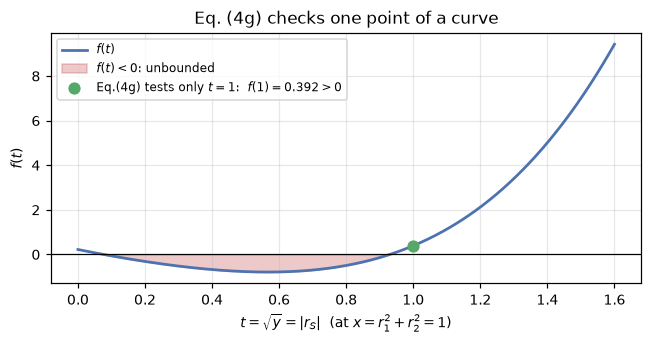

min over t >= 0 : -0.7891  at t = 0.565
closed form     : -0.7891
✓ Eq.(4g) passes at t=1 while f dips below zero elsewhere - exactly the counterexample


In [ ]:
A_n = float(lam_bad[0] + lam_bad[2])
B_n = float(lam_bad[4] + lam_bad[5] + 2 * lam_bad[6])
C_n, l8_n = 2 * abs(float(lam_bad[3])), float(lam_bad[7])
f = lambda t: l8_n * t**4 + B_n * t**2 - C_n * t + A_n

ts = np.linspace(0, 1.6, 400)
fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.plot(ts, f(ts), color="#4C72B0", lw=1.8, label=r"$f(t)$")
ax.axhline(0, color="black", lw=0.8)
ax.fill_between(ts, f(ts), 0, where=f(ts) < 0, color="#C44E52", alpha=0.3,
                label=r"$f(t)<0$: unbounded")
ax.plot([1], [f(1)], "o", color="#55A868", ms=7, zorder=5,
        label=r"Eq.(4g) tests only $t=1$:  $f(1)=%.3f>0$" % f(1))
ax.set_xlabel(r"$t=\sqrt{y}=|r_S|$  (at $x=r_1^2+r_2^2=1$)")
ax.set_ylabel(r"$f(t)$")
ax.set_title("Eq. (4g) checks one point of a curve")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("min over t >= 0 : %.4f  at t = %.3f" % (f(ts).min(), ts[int(np.argmin(f(ts)))]))
print("closed form     : %.4f" % neutral_real_bfb_min(lam_bad[None, :])[0])
assert f(1) > 0 > f(ts).min()
ok("Eq.(4g) passes at t=1 while f dips below zero elsewhere - exactly the counterexample")


### 5.5 The corrected condition

`constraints.neutral_real_bfb_min` minimizes $f(t)$ over $t\ge0$ in closed form (the
stationary points are the real positive roots of the cubic $f'$, found with batched
companion matrices), and `strict_bfb_mask` = Eq. (4) **and** $\min_t f\ge0$.

Its validation is the brute-force direction scan on the same slice — the two must agree on
every point, since one solves exactly what the other samples:


In [ ]:
closed = neutral_real_bfb_min(probe)
brute = numeric_bfb_min(m, probe, n_directions=60_000, seed=4, subspace="neutral-real")
disagree = int(((brute < -1e-6) != (closed < -1e-9)).sum())
print("closed form vs 60k-direction brute force over %d points: %d disagreements"
      % (len(probe), disagree))
assert disagree == 0
ok("the closed-form neutral condition reproduces brute-force sampling exactly")

print("\nimpact on the quoted conditions:")
print("  Eq.(4) acceptance                     : %.3f%%" % (100 * bfb_mask(pool).mean()))
print("  Eq.(4) + corrected neutral condition  : %.3f%%" % (100 * strict_bfb_mask(pool).mean()))
print("  fraction of Eq.(4) survivors removed  : %.2f%%"
      % (100 * (1 - strict_bfb_mask(pool).sum() / bfb_mask(pool).sum())))


closed form vs 60k-direction brute force over 400 points: 0 disagreements
✓ the closed-form neutral condition reproduces brute-force sampling exactly

impact on the quoted conditions:
  Eq.(4) acceptance                     : 5.759%
  Eq.(4) + corrected neutral condition  : 5.220%
  fraction of Eq.(4) survivors removed  : 9.35%


**Scope, stated honestly.** The corrected condition is exact on the real neutral slice, so
it is strictly stronger than Eq. (4g) — but it is still only *necessary*, not sufficient:
complex-neutral and charged directions are not covered by it. Full necessary-and-sufficient
BFB conditions for a 3HDM are a research problem in their own right (compare
[BotoRomaoSilva22], which solves other symmetry classes). So the scan below also carries an
**empirical backstop**: `model.numeric_bfb_min` samples the full 12-dimensional field space
on the surviving points, and any point with a negative direction is discarded.

Whether the 2015 erratum already corrects Eq. (4g) is not something this notebook can
settle — the erratum is not on arXiv and is paywalled. What it *can* say is that the
conditions as published in arXiv v2 are insufficient, and exactly why.


---
## 6. The scan

Nine parameters: the eight quartics and the vacuum angle θ.

- $\lambda_i\in U(-2,2)$ — deliberately **not** the tutorial's $U(0,1.5)$. Boundedness only
  requires $\lambda_1,\lambda_8>0$; forcing all eight positive presupposes part of the
  answer. The range stays well inside perturbativity ($|\lambda|<4\pi$).
- $\theta\in U(0.05,\pi/2-0.05)$, avoiding the endpoints where a VEV vanishes.

Every point is evaluated with numpy arrays — no Python loop over the sample.


In [ ]:
rng = np.random.default_rng(20260729)
N = 2_000_000

lam_scan = rng.uniform(-2.0, 2.0, size=(N, 8))
theta = rng.uniform(0.05, np.pi / 2 - 0.05, size=N)
v12_s = V_EW * np.sin(theta)
v2_s, vS_s = v12_s * np.sqrt(3) / 2, V_EW * np.cos(theta)

vspec = spectrum_function(m, "numpy")
t0 = time.time()
msq = vspec([lam_scan[:, i] for i in range(8)], v2_s, vS_s)
print("spectrum for %d points in %.2f s" % (N, time.time() - t0))


spectrum for 2000000 points in 3.08 s


The scan rests entirely on the vectorized spectrum, so it must reproduce the scalar one:


In [ ]:
scal = spectrum_function(m, "math")
idx_chk = rng.integers(0, N, size=25)
worst_rel = 0.0
for i in idx_chk:
    a = scal(list(lam_scan[i]), float(v2_s[i]), float(vS_s[i]))
    for key in SPECTRUM_KEYS:
        b = float(msq[key][i])
        worst_rel = max(worst_rel, abs(a[key] - b) / max(abs(a[key]), 1.0))
print("max relative difference (numpy vs math) over 25 random points: %.2e" % worst_rel)
assert worst_rel < 1e-10
ok("the vectorized spectrum agrees with the scalar one")


max relative difference (numpy vs math) over 25 random points: 0.00e+00
✓ the vectorized spectrum agrees with the scalar one


In [ ]:
no_tachyon = np.ones(N, dtype=bool)          # built in place: memory is tight here
for k in SPECTRUM_KEYS:
    no_tachyon &= msq[k] > 0
mass = {k: np.sqrt(np.clip(v, 0.0, None)) for k, v in msq.items()}
del msq                                      # ~130 MB, fully consumed above

cuts = {}
cuts["sampled"]         = np.ones(N, dtype=bool)
cuts["Eq.(4) bounded"]  = bfb_mask(lam_scan)
cuts["+ corrected BFB"] = cuts["Eq.(4) bounded"] & neutral_real_bfb_mask(lam_scan)
cuts["+ unitarity"]     = cuts["+ corrected BFB"] & unitarity_mask(lam_scan)
cuts["+ no tachyons"]   = cuts["+ unitarity"] & no_tachyon

# LEP direct search on charged scalars, as [GomezBock21] applies it
cuts["+ charged > 80"] = cuts["+ no tachyons"] & (mass["Hpm1"] > 80) & (mass["Hpm2"] > 80)

near125 = np.any(np.stack([np.abs(mass[k] - 125.0) <= 3.0
                           for k in ("h0", "H1", "H2")]), axis=0)
cuts["+ CP-even 125+-3"] = cuts["+ charged > 80"] & near125

prev = N
print("%-20s %9s %12s %12s" % ("cut", "surviving", "of sample", "of previous"))
for label, msk in cuts.items():
    n = int(msk.sum())
    print("%-20s %9d %11.3f%% %11.1f%%" % (label, n, 100 * n / N, 100 * n / prev))
    prev = max(n, 1)


cut                  surviving    of sample  of previous
sampled                2000000     100.000%       100.0%
Eq.(4) bounded          114293       5.715%         5.7%
+ corrected BFB         103465       5.173%        90.5%
+ unitarity             103465       5.173%       100.0%
+ no tachyons             7608       0.380%         7.4%
+ charged > 80            6890       0.344%        90.6%
+ CP-even 125+-3           322       0.016%         4.7%


The cut flow is a random sample, so its percentages need an error bar. Splitting it in half
and comparing is the cheapest meaningful check:


In [ ]:
half = N // 2
print("%-20s %10s %10s %10s" % ("cut", "half A", "half B", "|diff|/sigma"))
for label, msk in cuts.items():
    pa, pb = msk[:half].mean(), msk[half:].mean()
    sigma = math.sqrt(max(pa * (1 - pa), 1e-12) / half) * math.sqrt(2)
    z = abs(pa - pb) / sigma if sigma > 0 else 0.0
    print("%-20s %9.4f%% %9.4f%% %10.2f" % (label, 100 * pa, 100 * pb, z))
    assert z < 5.0
ok("the two halves of the sample agree within Poisson fluctuations")


cut                      half A     half B |diff|/sigma
sampled               100.0000%  100.0000%       0.00
Eq.(4) bounded          5.7187%    5.7106%       0.25
+ corrected BFB         5.1857%    5.1608%       0.79
+ unitarity             5.1857%    5.1608%       0.79
+ no tachyons           0.3767%    0.3841%       0.85
+ charged > 80          0.3407%    0.3483%       0.92
+ CP-even 125+-3        0.0161%    0.0161%       0.00
✓ the two halves of the sample agree within Poisson fluctuations


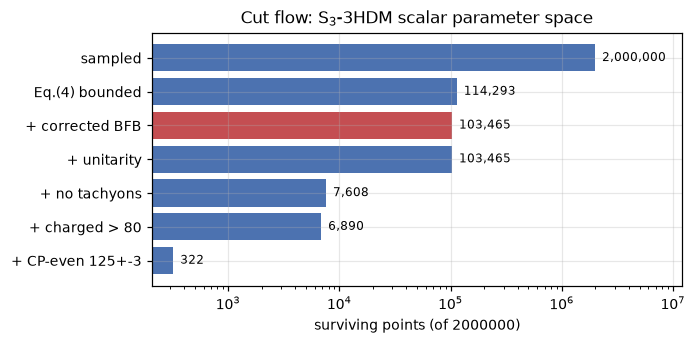

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
labels = list(cuts)
counts = [int(cuts[k].sum()) for k in labels]
colors = ["#4C72B0"] * len(labels)
colors[labels.index("+ corrected BFB")] = "#C44E52"
ax.barh(range(len(labels)), counts, color=colors)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel("surviving points (of %d)" % N)
ax.set_title("Cut flow: S$_3$-3HDM scalar parameter space")
for i, c in enumerate(counts):
    ax.text(c * 1.15, i, f"{c:,}", va="center", fontsize=8)
ax.set_xlim(right=N * 6)
plt.tight_layout(); plt.show()


Which individual condition does the work? (Fraction of the raw sample passing each one on
its own.)


In [ ]:
for k, v in constraint_report(lam_scan).items():
    print("  %-26s %.4f" % (k, v))


  BFB Eq.(4a)                0.5002
  BFB Eq.(4b)                0.4993
  BFB Eq.(4c)                0.5004
  BFB Eq.(4d)                0.3337
  BFB Eq.(4e)                0.6920
  BFB Eq.(4f)                0.3323
  BFB Eq.(4g)                0.2989
  BFB Eq.(4) all             0.0571
  neutral cond. (derived)    0.1119
  BFB strict                 0.0517
  unitarity Eq.(36)          1.0000
  combined                   0.0517


---
## 7. What the viable region looks like

Everything below uses the fully-cut sample: bounded (corrected condition), unitary, no
tachyons, charged scalars above the LEP bound.


viable points: 6890


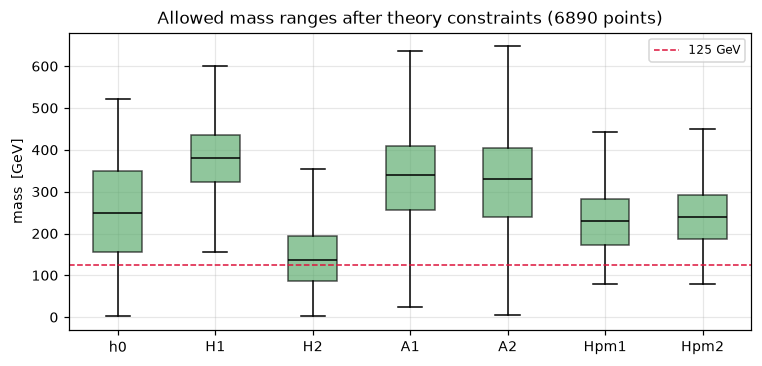


state       min   median     mean      max
h0          2.3    250.1    254.6    521.0
H1         78.3    381.2    381.6   1090.3
H2          1.6    137.3    145.2    438.7
A1          5.4    339.3    330.5    654.4
A2          6.2    330.0    322.5   1049.3
Hpm1       80.1    229.3    229.8    469.6
Hpm2       80.0    240.4    249.7   1025.6


In [ ]:
sel = cuts["+ charged > 80"]
print("viable points:", int(sel.sum()))

fig, ax = plt.subplots(figsize=(7.0, 3.4))
data = [mass[k][sel] for k in SPECTRUM_KEYS]
bp = ax.boxplot(data, tick_labels=list(SPECTRUM_KEYS), showfliers=False,
                patch_artist=True, medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor("#55A868"); patch.set_alpha(0.65)
ax.axhline(125, color="crimson", ls="--", lw=1, label="125 GeV")
ax.set_ylabel("mass  [GeV]"); ax.legend(fontsize=8)
ax.set_title("Allowed mass ranges after theory constraints (%d points)" % int(sel.sum()))
plt.tight_layout(); plt.show()

print("\n%-6s %8s %8s %8s %8s" % ("state", "min", "median", "mean", "max"))
for k in SPECTRUM_KEYS:
    d = mass[k][sel]
    print("%-6s %8.1f %8.1f %8.1f %8.1f" % (k, d.min(), np.median(d), d.mean(), d.max()))


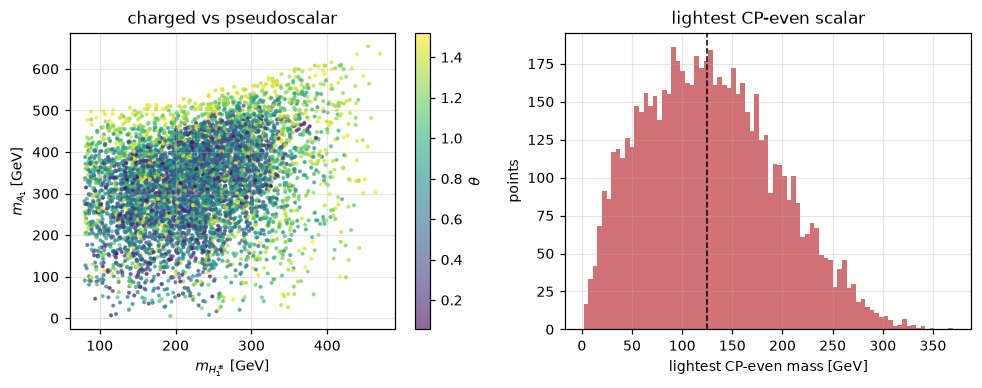

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))

sub = np.random.default_rng(1).choice(np.flatnonzero(sel),
                                      size=min(6000, int(sel.sum())), replace=False)
sc = axes[0].scatter(mass["Hpm1"][sub], mass["A1"][sub], c=theta[sub],
                     s=3, cmap="viridis", alpha=0.6)
axes[0].set_xlabel(r"$m_{H^\pm_1}$ [GeV]"); axes[0].set_ylabel(r"$m_{A_1}$ [GeV]")
axes[0].set_title("charged vs pseudoscalar")
plt.colorbar(sc, ax=axes[0], label=r"$\theta$")

lightest = np.min(np.stack([mass[k][sel] for k in ("h0", "H1", "H2")]), axis=0)
axes[1].hist(lightest, bins=80, color="#C44E52", alpha=0.8)
axes[1].axvline(125, color="black", ls="--", lw=1)
axes[1].set_xlabel("lightest CP-even mass [GeV]"); axes[1].set_ylabel("points")
axes[1].set_title("lightest CP-even scalar")
plt.tight_layout(); plt.show()


---
## 8. Benchmark points with a 125 GeV scalar

**Scope limit, stated explicitly.** A full SM-alignment test — [GomezBock21]'s scenarios A
and B, where one CP-even state couples maximally to $W/Z$ and the other decouples — needs
the **gauge–scalar couplings** of their Eq. (49). `examples/thdm_s3.py` declares *only* the
potential: no kinetic terms, no gauge bosons in the Lagrangian, so those couplings do not
exist to be computed. What follows is the **mass** condition alone. Adding the electroweak
kinetic sector is deferred (see `NOTES.md`).


In [ ]:
sel125 = cuts["+ CP-even 125+-3"]
idx = np.flatnonzero(sel125)
print("points with a CP-even state at 125 +- 3 GeV:", len(idx))


points with a CP-even state at 125 +- 3 GeV: 322


Before quoting any of them, apply the **full 12-dimensional boundedness backstop** of §5.5.
The analytic conditions cover the real neutral slice; this samples charged and
complex-neutral directions too, and discards any point with a direction where $V_4<0$.


In [ ]:
t0 = time.time()
full_min = numeric_bfb_min(m, lam_scan[idx], n_directions=40_000, seed=9, subspace="all")
survive = full_min >= -1e-9
print("checked %d points over 40k full-space directions in %.1f s"
      % (len(idx), time.time() - t0))
print("survive the full-space backstop: %d / %d  (%.1f%%)"
      % (int(survive.sum()), len(idx), 100 * survive.mean()))
idx = idx[survive]


checked 322 points over 40k full-space directions in 23.1 s
survive the full-space backstop: 319 / 322  (99.1%)


In [ ]:
records = []
for i in idx[:12]:
    records.append({
        "lambdas": {f"lambda_{k+1}": round(float(lam_scan[i, k]), 5) for k in range(8)},
        "theta": round(float(theta[i]), 5),
        "vevs_GeV": {"v1": round(float(v12_s[i] / 2), 3),
                     "v2": round(float(v2_s[i]), 3),
                     "vS": round(float(vS_s[i]), 3)},
        "masses_GeV": {k: round(float(mass[k][i]), 2) for k in SPECTRUM_KEYS},
    })

for rec in records[:3]:
    print("theta = %.4f   vevs = %s" % (rec["theta"], rec["vevs_GeV"]))
    print("  masses:", rec["masses_GeV"], "\n")


theta = 0.8106   vevs = {'v1': 89.139, 'v2': 154.394, 'vS': 169.507}
  masses: {'h0': 498.79, 'H1': 356.41, 'H2': 125.61, 'A1': 136.74, 'A2': 283.56, 'Hpm1': 304.3, 'Hpm2': 193.11} 

theta = 1.2348   vevs = {'v1': 116.121, 'v2': 201.128, 'vS': 81.113}
  masses: {'h0': 408.81, 'H1': 472.33, 'H2': 127.24, 'A1': 480.83, 'A2': 169.17, 'Hpm1': 324.5, 'Hpm2': 271.26} 

theta = 0.3788   vevs = {'v1': 45.485, 'v2': 78.782, 'vS': 228.562}
  masses: {'h0': 278.41, 'H1': 368.69, 'H2': 127.47, 'A1': 394.11, 'A2': 380.56, 'Hpm1': 225.18, 'Hpm2': 224.86} 



Final validation of the quoted points: the scan reads masses from the analytic rotation
ansatz, so re-derive them by brute-force numeric diagonalization of the un-rotated
matrices, in all three sectors.


In [ ]:
bad = 0
for i in idx[:12]:
    res = check_sectors_against_eigenvals(m, list(lam_scan[i]), float(v2_s[i]),
                                          float(vS_s[i]))
    bad += sum(not agree for _, _, agree in res.values())
print("sector cross-checks failed:", bad, "of", 3 * len(records))
assert bad == 0
ok("every benchmark point reproduces under independent numeric diagonalization")


sector cross-checks failed: 0 of 36
✓ every benchmark point reproduces under independent numeric diagonalization


In [ ]:
out = Path("results/viable_points.json")
out.parent.mkdir(exist_ok=True)
payload = {
    "description": ("S3-3HDM scalar parameter points surviving boundedness-from-below "
                    "([DasDey14] Eq.4 PLUS the corrected neutral condition derived in "
                    "notebook section 5, PLUS a full 12-dimensional numerical backstop), "
                    "tree unitarity [DasDey14] Eq.36-37, no tachyons, m_Hpm > 80 GeV, "
                    "and one CP-even state at 125 +- 3 GeV."),
    "electroweak_scale_GeV": V_EW,
    "sample_size": int(N),
    "rng_seed": 20260729,
    "lambda_range": [-2.0, 2.0],
    "boundedness": {
        "quoted_conditions": "[DasDey14] Eq.(4a)-(4g), arXiv v2 (pre-erratum)",
        "correction": "min_{t>=0} [ l8 t^4 + (l5+l6+2 l7) t^2 - 2|l4| t + (l1+l3) ] >= 0",
        "numeric_backstop_directions": 40000,
    },
    "cut_flow": {k: int(v.sum()) for k, v in cuts.items()},
    "points": records,
}
out.write_text(json.dumps(payload, indent=2))
print("wrote", out, "(%d benchmark points, %.1f kB)" % (len(records), out.stat().st_size / 1024))


wrote results/viable_points.json (12 benchmark points, 7.7 kB)


---
## 9. Findings

1. **The tutorial's benchmark vacuum sits at $v=155$ GeV, not 246.** Imposing the √3
   alignment as a substitution silently overwrites $v_1$ and breaks the scale constraint
   that motivated the original numbers. Every mass quoted in its §9 is low by a factor
   1.587. The fix is to impose both conditions at once (`aligned_vevs`), leaving θ as the
   one free vacuum parameter. The alignment itself is not an input: it is forced by the
   over-constrained tadpole system, whose residual $\tfrac32\lambda_4v_S(3v_1^2-v_2^2)$
   vanishes only on $v_2=\sqrt3v_1$ (§2.1).

2. **The tutorial's benchmark λ's are not a viable theory** — the potential is not bounded
   from below there. "5 of 7 states are tachyonic" was a symptom; the point was never
   admissible.

3. **feynlag's λ basis is *not* [DasDey14]'s, and the difference is exactly one sign.**
   The λ₄ invariant transcribed literally from the paper fails S₃ invariance in feynlag's
   real-orthogonal irrep basis (§4). Seven of the eight quartic structures are invariant
   under *any* $SO(2)$ rotation of the doublet, so their coefficients transfer directly;
   only $s\cdot d_2$ can change, and the sole S₃-preserving transformation that changes it
   is $H_{1,2}\to-H_{1,2}$, which sends $\lambda_4\to-\lambda_4$. Matching feynlag's masses
   to [GomezBock21] Eqs. (30)–(33) fixes the sign ($e=-\lambda_4$) and validates the whole
   chain against published closed forms. Because the sign flip is a field redefinition, no
   physical condition may depend on it — and indeed λ₄ enters the constraints only as
   $|\lambda_4|$ or $\lambda_4^2$, so they transfer unchanged.

4. **The published boundedness conditions are not sufficient** (§5.3–§5.5). Roughly **10%**
   of the λ points that [DasDey14] Eq. (4) accepts have an explicit real neutral direction
   along which $V_4<0$. The cause is exact and simple: on that slice boundedness requires
   $f(t)=\lambda_8t^4+(\lambda_5+\lambda_6+2\lambda_7)t^2-2|\lambda_4|t+(\lambda_1+\lambda_3)\ge0$
   for **all** $t\ge0$, and Eq. (4g) is precisely $f(1)>0$ — one point of that curve. The
   corrected condition is derived, implemented (`constraints.neutral_real_bfb_min`) and
   validated against brute-force sampling. Whether the un-obtainable 2015 erratum already
   fixes this is an open question; the insufficiency of the arXiv v2 conditions is not.

5. **Boundedness, not unitarity, is the binding constraint** in this λ range. Tree unitarity
   ($|a|\le16\pi$) is essentially never violated for $|\lambda|\le2$ — it would only bite at
   $|\lambda|\gtrsim$ several — while boundedness removes the overwhelming majority of
   points, and the corrected condition removes another ~10% on top of Eq. (4).

6. **The viable spectra cluster below a TeV**, consistent with [DasDey14]'s own conclusion
   that "many new scalars must be lurking below 1 TeV".

## Open questions

- **Get the erratum.** [DasDey14]'s Erratum (Phys. Rev. D **91**, 039905) is not on arXiv
  and is paywalled. It may already correct Eq. (4g); it may also touch the unitarity
  eigenvalues, which this notebook checks for internal consistency but cannot check against
  a corrected source. A cross-check of the unitarity bounds against [BentoRomaoSilva22],
  which post-dates the erratum, is the natural next step.
- **Complete the boundedness conditions.** The corrected condition is exact on the real
  neutral slice only. Complex-neutral and charged directions are currently covered by
  numerical sampling, not analytically.
- **The 125 GeV cut is a mass condition only.** Testing [GomezBock21]'s alignment scenarios
  A/B needs the gauge–scalar couplings, which requires adding the electroweak kinetic
  sector to the model.
- The scan samples λ uniformly; the viable region's shape makes that inefficient. A targeted
  sampler would resolve its boundary far better.
- Does the S₃ fermion sector further constrain this region? See `NOTES.md`.


---
## 10. References

- **[GomezBock21]** M. Gómez-Bock, M. Mondragón, A. Pérez-Martínez, *"Scalar and gauge
  sectors in the 3-Higgs Doublet Model under the S₃-symmetry"*, Eur. Phys. J. C **81**, 942
  (2021), [arXiv:2102.02800](https://arxiv.org/abs/2102.02800) (v3, Oct 2021),
  [doi:10.1140/epjc/s10052-021-09731-3](https://doi.org/10.1140/epjc/s10052-021-09731-3).
- **[DasDey14]** D. Das, U. K. Dey, *"Analysis of an extended scalar sector with S₃
  symmetry"*, Phys. Rev. D **89**, 095025 (2014),
  [arXiv:1404.2491](https://arxiv.org/abs/1404.2491) (v2, May 2014),
  [doi:10.1103/PhysRevD.89.095025](https://doi.org/10.1103/PhysRevD.89.095025).
  **Erratum: Phys. Rev. D 91, 039905 (2015)** — not posted to arXiv; the conditions used
  here are transcribed from the pre-erratum arXiv v2.
- **[BentoRomaoSilva22]** M. P. Bento, J. C. Romão, J. P. Silva, *"Unitarity bounds for all
  symmetry-constrained 3HDMs"*, JHEP **08** (2022) 273,
  [arXiv:2204.13130](https://arxiv.org/abs/2204.13130),
  [doi:10.1007/JHEP08(2022)273](https://doi.org/10.1007/JHEP08(2022)273).
- **[BotoRomaoSilva22]** R. Boto, J. C. Romão, J. P. Silva, *"Bounded from below conditions
  on a class of symmetry constrained 3HDM"*, Phys. Rev. D **106**, 115010 (2022),
  [arXiv:2208.01068](https://arxiv.org/abs/2208.01068),
  [doi:10.1103/PhysRevD.106.115010](https://doi.org/10.1103/PhysRevD.106.115010).

### Where each imported result is used

| result | source | used in | confirmed by |
|---|---|---|---|
| $\sqrt{\sum v_i^2}=v=246$ GeV | [GomezBock21] Eq. (8) | §2.3 | — (definition) |
| √3 vacuum alignment | [GomezBock21] Eq. (13) | §2.1 | **derived here** from the tadpole residual |
| θ parametrization | [GomezBock21] Eq. (24) | §2.3 | assertion in §2.3 |
| geometric rotation $R$ | [GomezBock21] Eqs. (25)–(29) | §3.1 | $R^{\mathsf T}R=1$; Goldstones exactly 0 |
| closed-form $A_{1,2}$, $H^\pm_{1,2}$ masses | [GomezBock21] Eqs. (30)–(33) | §4.2 | reproduced exactly by feynlag |
| boundedness Eq. (4a)–(4g) | [DasDey14] (arXiv v2) | §5 | **falsified as sufficient** in §5.3 |
| unitarity Eq. (36), (37a)–(37l) | [DasDey14] (arXiv v2) | §5 | typeset↔code identity; discriminants ≥ 0 |
| alignment scenarios A/B | [GomezBock21] Eqs. (54)–(55) | §8 (scope note) | out of scope — no gauge sector |

Reference notes for the follow-on directions ([BabuWuXu23] for the S₃ fermion sector,
[Yildirim26] as a constraint cross-check target) are kept in
[`NOTES.md`](NOTES.md).
